![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Tokenización de textos  

En este taller podrán poner en práctica sus conocimientos sobre preprocesamiento de texto (tokenización). El taller está constituido por 5 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos detección de toxicidad en comentarios

En este taller se usará el conjunto de datos de detección de toxicidad en comentarios de la base de datos de Kaggle. Cada observación es un comentario que tiene como variable objetivo (target) la probabilidad de ser un comentario tóxico. El objetivo es predecir la toxicidad de cada comentario. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/c/jigsaw-unintended-bias-in-toxicity-classification/data).

In [98]:
# SUGERIDO: Descomenta la siguiente linea de código si requieres instalar las libreías básicas utilizadas en este notebook
# Si requieres incluir más librerías puedes agregarlas al archivo Semana 4\requirements.txt
# !pip install -r requirements.txt

In [99]:
import warnings
warnings.filterwarnings('ignore')

In [100]:
# Importación librerías
import pandas as pd
import numpy as np
import scipy as sp
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn import metrics
%matplotlib inline

In [101]:
# Carga de datos de archivos .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/Toxicity.zip')
df = df[['id','comment_text', 'target']]
df.head()

,id,comment_text,target
0,6101457,What are you talking about? What group do Pete...,0.0
1,5342103,"NO!, Let him, we need a Conservative government.",0.0
2,743361,"Perhaps he took the ""power out of the Cardinal...",0.2
3,551008,"As always, yours is dripping with sarcasm, whi...",0.0
4,865998,The dirty little secret is that the price rang...,0.3


In [102]:
df.shape

(541462, 3)

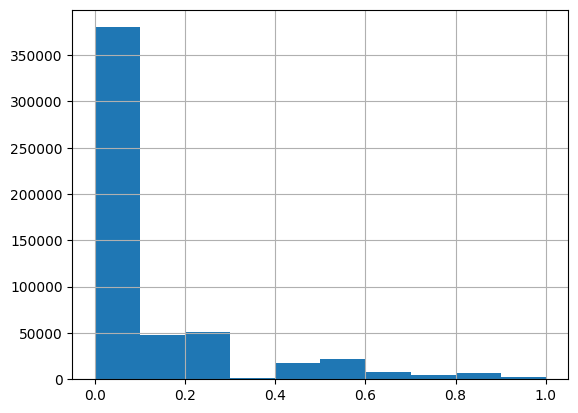

In [103]:
# Impresión histograma de variable de interés (y)
df.target.hist()
plt.show()

In [104]:
# Separación de variable de interés (y)
y = df.target
y.describe()

count    541462.000000
mean          0.102991
std           0.196979
min           0.000000
25%           0.000000
50%           0.000000
75%           0.166667
max           1.000000
Name: target, dtype: float64

In [105]:
# Separación de variables predictoras (X), solo se considera el texto de la noticia
X = df.comment_text

In [106]:
# Separación de datos en set de entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Punto 1 - Tokenización con CountVectorizer

En la celda 1 creen y entrenen el modelo de regresión de su preferencia, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función **CountVectorizer** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [107]:
# Celda 1
from sklearn.metrics import mean_squared_error
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import Ridge
import time


start_p1 = time.time()
# Tokenización
vect1 = CountVectorizer()

# Ajustar con train
X_train_dtm = vect1.fit_transform(X_train)

# Transformar test con el mismo vocabulario
X_test_dtm = vect1.transform(X_test)

# Crear y entrenar el modelo de regresión Ridge
modelo1 = Ridge(alpha=1.0)
modelo1.fit(X_train_dtm, y_train)

# Predicciones
y_pred_1 = modelo1.predict(X_test_dtm)

# Evaluación con MSE
mse_1 = mean_squared_error(y_test, y_pred_1)
print("MSE del modelo con regresión RIDGE:", mse_1)

end_p1 = time.time()
time_p1 = end_p1 - start_p1


MSE del modelo con regresión RIDGE: 0.026127476612697768


## Punto 2 - Tokenización con CountVectorizer y trigramas

En la celda 2 creen y entrenen el mismo modelo de regresión del punto anterior (es decir si usaron un RandomForestRegresor usen nuevamente ese regresor), para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Usen la función CountVectorizer **considerando trigramas** para preprocesar los comentarios y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [108]:

# Celda 2
start_p2 = time.time()

vect_2 = CountVectorizer(ngram_range=(1,3))

X_train_dtm_2 = vect_2.fit_transform(X_train)
X_test_dtm_2 = vect_2.transform(X_test)

modelo_2 = Ridge(alpha=1)

modelo_2.fit(X_train_dtm_2, y_train)

y_pred_2 = modelo_2.predict(X_test_dtm_2)

mse_2 = mean_squared_error(y_test, y_pred_2)
print("MSE del modelo:", mse_2)

end_p2 = time.time()
time_p2 = end_p2 - start_p2

MSE del modelo: 0.03332211679750376


## Punto 3 - TfidfVectorizer

Investigen sobre la función TfidfVectorizer. En la celda de texto 3, expliquen en qué consiste esta técnica de tokenización (describanla y expliquen su funcionamiento) y cúales son las ventajas o deventajas de su uso al compararlo con la función CountVectorizer.

#### Celda 3

#### ¿Qué es TF-IDF?

La técnica TF-IDF (Term Frequency - Inverse Document Frequency) es un método de vectorización que busca reflejar la importancia de una palabra dentro de un documento en relación con un conjunto de documentos (corpus). A diferencia de los métodos que solo cuentan palabras, TF-IDF penaliza las palabras que aparecen con demasiada frecuencia en todos los documentos (como artículos o preposiciones) y resalta aquellas que son distintivas del contenido específico.

TF-IDF es una técnica de representación numérica de texto que asigna un peso a cada término en función de dos factores:
1. ***TF (frecuencia de término)***<br>
   Qué tan frecuente es la palabra dentro del documento<br>
   $\text{tf}(t,d) = \frac{\text{veces que } t \text{ aparece en } d}{\text{total de palabras en } d}$ 

2. ***IDF (frecuencia inversa de documento)***<br>
   Qué tan rara es la palabra en la colección completa<br>
   $\text{idf}(t) = \log\frac{1 + N}{1 + \text{df}(t)} + 1$

3. **TF-IDF**<br>
    Peso final del término<br>
    $\text{tfidf}(t,d) = \text{tf}(t,d) \times \text{idf}(t)$

    Donde $N$ es el número total de documentos y $\text{df}(t)$ el número de documentos que contienen el término $t$.

#### ¿Cómo funciona?
Palabras que aparecen mucho en un documento pero poco en el corpus reciben pesos altos (son discriminativas).
Palabras muy comunes en todos los documentos (the, is, and) reciben pesos bajos, incluso si aparecen frecuentemente en un texto.
La matriz resultante se normaliza (norma L2) para que los documentos largos y cortos sean comparables.


#### Ventajas 
* Reduce la importancia de palabras muy comunes. Filtra automáticamente el "ruido" de palabras comunes (como "el", "de", "que") sin necesidad de una lista extensa de stop words.
* Resalta palabras más informativas.
* Generalmente mejora el desempeño en tareas de clasificación y regresión de texto.
* Más robusto ante documentos de longitudes muy distintas.

#### Desventajas 
* Es más costoso computacionalmente que CountVectorizer
* Puede ser más difícil de interpretar
* El modelo solo cuenta palabras o calcula su frecuencia, pero no entiende el significado real del lenguaje.
* No considera el orden del texto (a menos que se usen n-gramas)

## Punto 4 - Tokenización con TfidfVectorizer

En la celda 4 creen y entrenen el mismo modelo de regresión del primer punto, para que prediga la probabilidad de que un comentario sea tóxico, usando los set de entrenamiento y test definidos anteriormente. Procesen los comentarios con la función **TfidfVectorizer** y presenten el desempeño del modelo con la métrica del MSE.

Recuerden que el preprocesamiento que se haga sobre los datos de entrenamiento  (*.fit_transform()*) deben ser aplicado al set de test (*.transform()*).

In [109]:
# Celda 4

from sklearn.feature_extraction.text import TfidfVectorizer

start_p3 = time.time()

vect_3 = TfidfVectorizer()

X_train_dtm_3 = vect_3.fit_transform(X_train)
X_test_dtm_3 = vect_3.transform(X_test)

modelo_3 = Ridge(alpha=1)

modelo_3.fit(X_train_dtm_3, y_train)

y_pred_3 = modelo_3.predict(X_test_dtm_3)

mse_3 = mean_squared_error(y_test, y_pred_3)

print("MSE del modelo:", mse_3)

end_p3 = time.time()
time_p3 = end_p3 - start_p3


MSE del modelo: 0.018051276808344476


## Punto 5 - Comparación y análisis de resultados

En la celda 5 comparen los resultados obtenidos de los diferentes modelos y comenten cómo el preprocesamiento de texto afecta el desempeño.


📊 COMPARACIÓN DE MODELOS


           COMPARACIÓN DE MODELOS DE TOKENIZACIÓN
Punto                     Vectorizador Modelo  Vocab. términos  MSE (test)
   P1     CountVectorizer\n(unigramas)  Ridge           141176    0.026127
   P2 CountVectorizer\n(trigramas 1-3)  Ridge         14221994    0.033322
   P4     TfidfVectorizer\n(unigramas)  Ridge           141176    0.018051

📊 GRÁFICO MSE



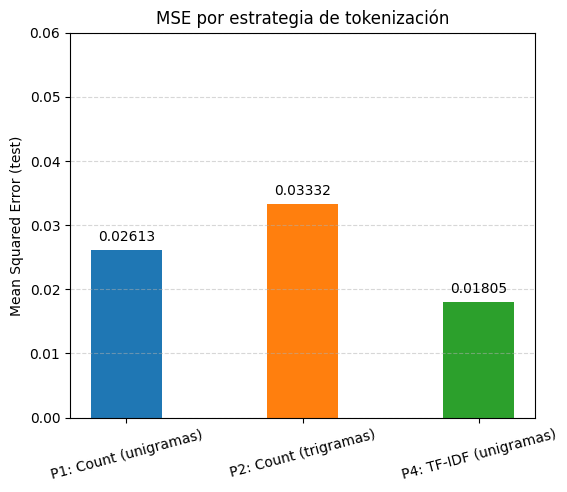


📊 TAMAÑO DEL VOCABULARIO GENERADO



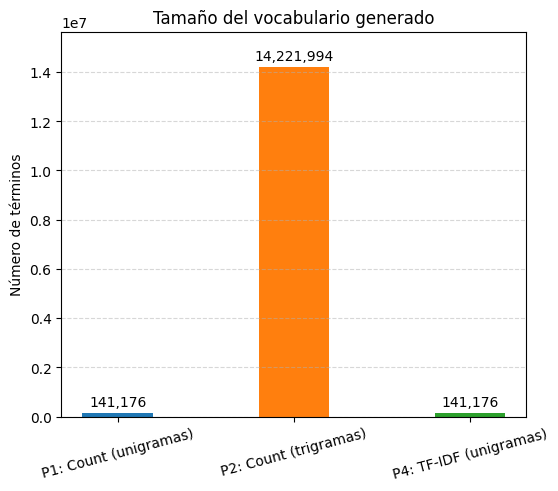


📊 TIEMPO DE CÁLCULO PARA CADA MODELO



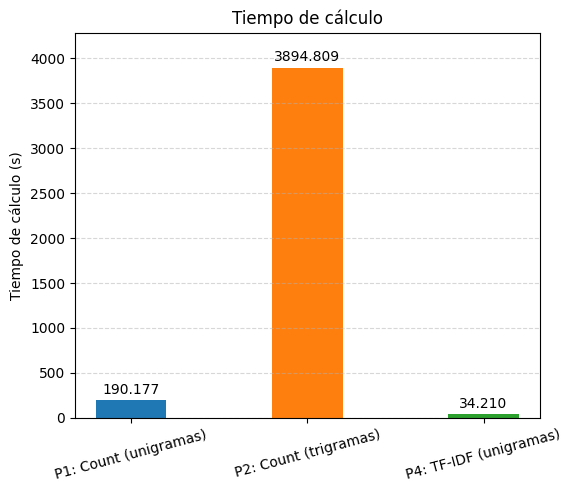

In [110]:
# Celda 5 Código para graficos y tablas comparativas
import matplotlib.pyplot as plt

# Tabla resumen 
# =================================================================================
print("\n\033[1;34m📊 COMPARACIÓN DE MODELOS\033[0m\n")

resultados = pd.DataFrame({
    'Punto'         : ['P1', 'P2', 'P4'],
    'Vectorizador'  : ['CountVectorizer\n(unigramas)',
                       'CountVectorizer\n(trigramas 1-3)',
                       'TfidfVectorizer\n(unigramas)'],
    'Modelo'        : ['Ridge'] * 3,
    'Vocab. términos': [X_train_dtm.shape[1],
                        X_train_dtm_2.shape[1],
                        X_train_dtm_3.shape[1]],
    'MSE (test)'    : [mse_1, mse_2, mse_3]
})

print("\n" + "="*65)
print("           COMPARACIÓN DE MODELOS DE TOKENIZACIÓN")
print("="*65)
print(resultados.to_string(index=False))
print("="*65)


# Gráfico MSE
# ====================================================================================
print("\n\033[1;34m📊 GRÁFICO MSE\033[0m\n")
mse_values = [mse_1, mse_2, mse_3]
labels = ['P1: Count (unigramas)', 'P2: Count (trigramas)', 'P4: TF-IDF (unigramas)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, mse_values, color=colors, width=0.4)

# Etiquetas numéricas encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.001,
             f'{height:.5f}', ha='center', va='bottom')

plt.ylabel('Mean Squared Error (test)')
plt.title('MSE por estrategia de tokenización')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, 0.06)
plt.show()

# Gráfico Tamaño de vocabulario
# =====================================================================================
print("\n\033[1;34m📊 TAMAÑO DEL VOCABULARIO GENERADO\033[0m\n")
vocab_sizes = [X_train_dtm.shape[1], X_train_dtm_2.shape[1], X_train_dtm_3.shape[1]]
labels = ['P1: Count (unigramas)', 'P2: Count (trigramas)', 'P4: TF-IDF (unigramas)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, vocab_sizes, color=colors, width=0.4)

# Etiquetas numéricas encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(vocab_sizes)*0.01,
             f'{height:,}', ha='center', va='bottom')

plt.ylabel('Número de términos')
plt.title('Tamaño del vocabulario generado')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, 1.1*(max(vocab_sizes)))
plt.show()


# Gráfico Timpo de cálculo 
# =====================================================================================
print("\n\033[1;34m📊 TIEMPO DE CÁLCULO PARA CADA MODELO\033[0m\n")

tiempos=[time_p1, time_p2, time_p3]

labels = ['P1: Count (unigramas)', 'P2: Count (trigramas)', 'P4: TF-IDF (unigramas)']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, tiempos, color=colors, width=0.4)

# Etiquetas numéricas encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(tiempos)*0.01,
             f'{height:.3f}', ha='center', va='bottom')

plt.ylabel('Tiempo de cálculo (s)')
plt.title('Tiempo de cálculo')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, 1.1*(max(tiempos)))
plt.show()

### Punto 5.1 - Comparación y análisis de resultados

* El modelo que utiliza TF-IDF con unigramas obtuvo un mejor desempeño que con el menor valor de MSE, lo que indica una mejor capacidad para predecir la variable de respuesta, seguido por CountVectorizer con trigramas y finalmente CountVectorizer con unigramas.
  
* De la tabla y el gráfico MSE se observa como el preprocesamiento tiene un impacto significativo en el desempeño del modelo, medido por el error cuadrático medio (MSE). Esto muestra que el tipo de representación del texto tiene un impacto directo en la capacidad del modelo para capturar patrones relevantes de toxicidad.
* Al pasar de unigramas a trigramas, el tamaño del vocabulario se incrementa drásticamente. Esto introduce muchas más características, la mayoría muy raras (baja frecuencia), lo que puede generar ruido. Si el MSE baja, los n-gramas capturan frases tóxicas relevantes.
* CountVectorizer usa conteos brutos: palabras muy comunes dominan la representación aunque no aporten información discriminativa. TfidfVectorizer penaliza automáticamente esas palabras y premia los términos más específicos, resultando generalmente en un menor MSE para este tipo de tarea, tal como se ve en el "Gráfico MSE".
* Más términos no implica siempre mejor desempeño. La calidad del preprocesamiento (ponderación, normalización) suele importar más que la cantidad de características. TF-IDF logra un balance mejor entre riqueza léxica y representación significativa. Por ejemplo, el vocabulario para CountVectorizer con trigramas es mucho mayor per para TF-IDF, sin embargo el MSE resulta mayor.
* En la última gráfica "Tiempo de cálculo" se observa como para CountVectorizer (trigramas) el tiempo de cáclulo es el más alto, mientras pra TF-IDF es el más bajo, este estaría asociado al tamaño del vocabulario generado en cada modelo.
* En conclusión, para la predicción de toxicidad, TfidfVectorizer es preferible a CountVectorizer básico porque normaliza por longitud del documento, reduce el peso de términos comunes sin eliminarlos, produce representaciones más informativas para el modelo.